# 📈 Pre-approval credit risk scorer
## Summary
**Objective:** Predict loans that are most likely to end in a **Default** status and their probability. 

Note: Internal bank metrics such as loan grade and interest rate were intentionally excluded to simulate a real world pre-approval risk assessment.

**Dataset:** 2.2M records from Lending Club (2007 to 2018), reduced to 1.3M samples for project's purpose.

**Target:** Binary classification (**Paid off** vs  **Default**) with a significant 80:20 class imbalance.

**Model:** **XGBoost** optimized using **Optuna**.

### Performance:
**Gini coefficient**: 0.402

**ROC AUC score**: 0.701

**Recall (balanced)**: 0.64

# 📥 Data loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/kaggle/input/lending-club/accepted_2007_to_2018Q4.csv.gz')


In [2]:
print(data.shape)

(2260701, 151)


## Feature selection

The original dataset contains 151 columns and 2.2M records. To ensure that the Streamlit website will be user friendly, I select a small subset of features that user can easily provide, excluding internal bank data.

In [3]:
%%capture

pd.options.display.max_rows = 151
data.head().T.sort_index()

 **Selected features and short descriptions**:



**loan_amnt**: The listed amount of the loan.

**term**: The number of payments on the loan.

**fico_range_low**: The lower boundary range the borrower's FICO at loan origination belongs to.

**fico_range_high**:The upper boundary range the borrower's FICO at loan origination belongs to.

**pub_rec**: Number of derogatory public records.

**emp_length**: Employment duration.

**home_ownership**: The home ownership status.

**annual_inc**: Borrower's annual income.

**purpose**: A category provided by the borrower for the loan request.

**dti**: A ratio calculated using the borrower’s total monthly debt payments divided by monthly gross income.

**revol_util**: The amount of credit the borrower is using relative to all available revolving credit.

**mort_acc**: Number of mortgage accounts.

**earliest_cr_line**: The month and year the borrower's earliest reported credit line was opened.

**open_acc**: The number of open credit lines in the borrower's credit file.

**issue_d**: The date loan was issued.

**loan_status**: Status of the loan (target).

In [4]:
keep_cols = [
    'loan_amnt',
    'term',
    'fico_range_low',
    'fico_range_high', 
    'pub_rec', 
    'emp_length',
    'home_ownership',
    'annual_inc', 
    'purpose',
    'dti',
    'revol_util',
    'mort_acc',
    'earliest_cr_line',
    'open_acc',
    'issue_d',
    'loan_status'
]
data = data[keep_cols]
data.head()

,loan_amnt,term,fico_range_low,fico_range_high,pub_rec,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,mort_acc,earliest_cr_line,open_acc,issue_d,loan_status
0,3600.0,36 months,675.0,679.0,0.0,10+ years,MORTGAGE,55000.0,debt_consolidation,5.91,29.7,1.0,Aug-2003,7.0,Dec-2015,Fully Paid
1,24700.0,36 months,715.0,719.0,0.0,10+ years,MORTGAGE,65000.0,small_business,16.06,19.2,4.0,Dec-1999,22.0,Dec-2015,Fully Paid
2,20000.0,60 months,695.0,699.0,0.0,10+ years,MORTGAGE,63000.0,home_improvement,10.78,56.2,5.0,Aug-2000,6.0,Dec-2015,Fully Paid
3,35000.0,60 months,785.0,789.0,0.0,10+ years,MORTGAGE,110000.0,debt_consolidation,17.06,11.6,1.0,Sep-2008,13.0,Dec-2015,Current
4,10400.0,60 months,695.0,699.0,0.0,3 years,MORTGAGE,104433.0,major_purchase,25.37,64.5,6.0,Jun-1998,12.0,Dec-2015,Fully Paid


# 🎯Target definition & analysis

In [5]:
print(data['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


I simplify the `loan_status` into a binary target using a strict default definition:

-**Positive class (1):** Any loan with a status other than "Fully Paid" (every Late and Charged Off case).

-**Negative class (0):** Only "Fully Paid" loans.

-**Drop:** "Current" and "In Grace Period" loans

In [6]:
data.loc[data['loan_status']=='Does not meet the credit policy. Status:Fully Paid','loan_status']='Fully Paid'
data.loc[data['loan_status']=='Does not meet the credit policy. Status:Charged Off','loan_status']='Default'
data.loc[data['loan_status']=='Late (31-120 days)','loan_status']='Default'
data.loc[data['loan_status']=='Late (16-30 days)','loan_status']='Default'
data.loc[data['loan_status']=='Charged Off','loan_status']='Default'
data = data.loc[(data['loan_status']=='Fully Paid')|(data['loan_status']=='Default')]
data['target_num'] = (data['loan_status'] == 'Default').astype(int)
print(f'New data shape: {data.shape}')

New data shape: (1373915, 17)


loan_status
Fully Paid    0.785157
Default       0.214843
Name: count, dtype: float64


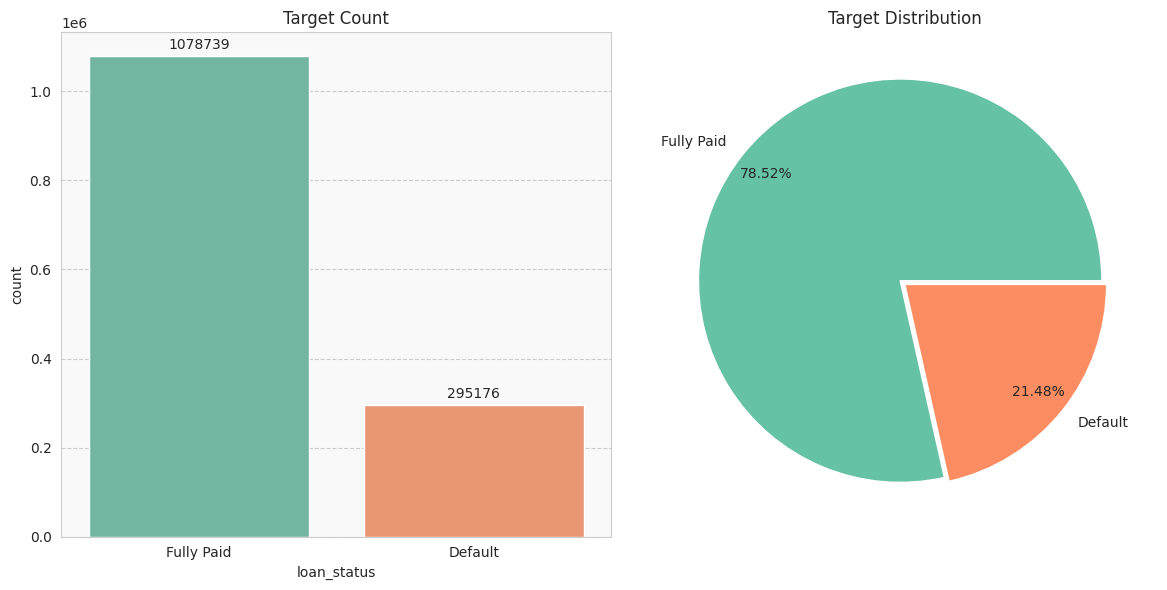

In [7]:
counts =data['loan_status'].value_counts()
print(counts/len(data))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.6})
colors = sns.color_palette("Set2")
fig,axes = plt.subplots(1,2,figsize=(12,6))
ax=sns.countplot(data=data,x='loan_status',palette=colors,ax=axes[0])
axes[0].set_title('Target Count')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)
axes[0].set_facecolor('#f9f9f9')

axes[1].pie(x=counts.values,labels=counts.index,colors=colors,autopct='%1.2f%%',pctdistance=0.85,explode=(0.03,0))
axes[1].set_title('Target Distribution')
plt.tight_layout()

## Observation
The target variable is imbalanced, with only approximately 20% of loans ending in a **Default** status. This distribution is a critical factor to consider for training and evaluation.

A lazy model could achieve around 80% accuracy by simply predicting **Fully Paid** for every client. To prevent this, I need to focus on the metrics like ROC AUC score, Gini coefficient, precision, recall, and F1-score.

# ✂️ Train test split

I split the data into a 90% train set and a 10% test set. I use stratified sampling to ensure that the percentages of **Default** statuses are the same in both sets. I combine X_train with y_train into one data frame called **train** only for analysis and visualization.

In [8]:
from sklearn.model_selection import train_test_split
X = data.drop(['loan_status','target_num'],axis=1)
y= data['target_num']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=10,test_size=0.1,stratify=y)
train = pd.concat([X_train,y_train],axis=1)
train['loan_status'] = data['loan_status']

# 🔍 Missing Data Analysis
Before cleaning, I need to understand the scale of missing values.

Train set
All rows: 1236523
                  Count  Fraction
emp_length        72780  0.058859
mort_acc          45031  0.036417
revol_util          843  0.000682
dti                 357  0.000289
earliest_cr_line     27  0.000022
open_acc             27  0.000022
pub_rec              27  0.000022
annual_inc            4  0.000003


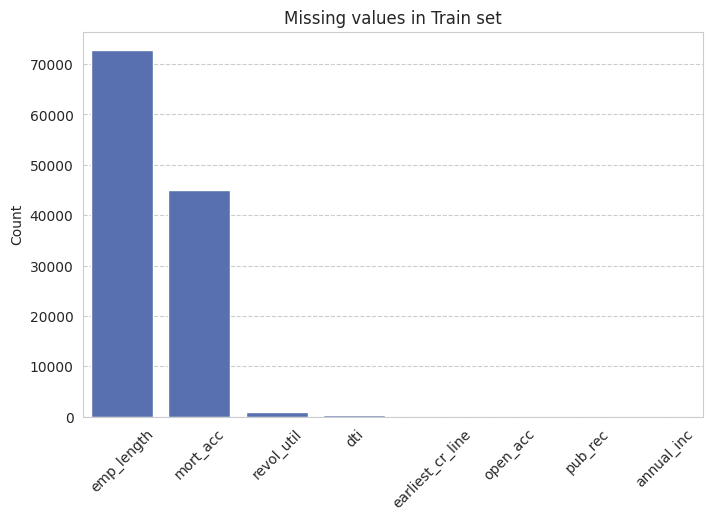

Test set
All rows: 137392
                  Count  Fraction
emp_length         8070  0.058737
mort_acc           4999  0.036385
revol_util           84  0.000611
dti                  46  0.000335
earliest_cr_line      2  0.000015
pub_rec               2  0.000015
open_acc              2  0.000015


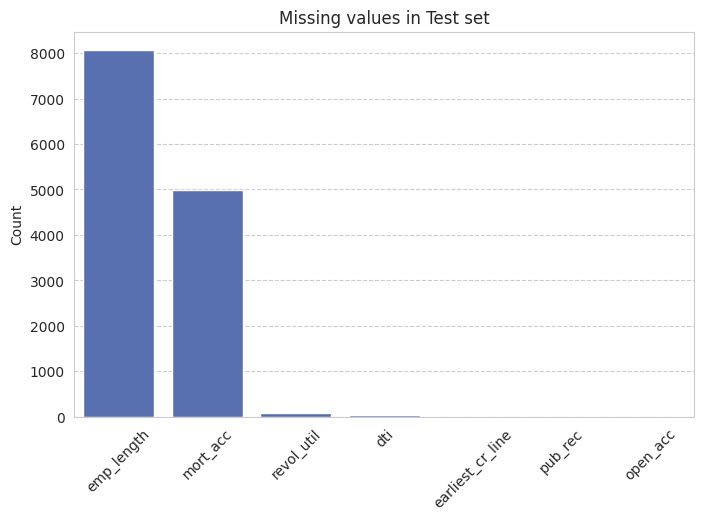

In [9]:
def analyze_missing(df, name=""):
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_df = pd.DataFrame(missing).rename(columns={0: 'Count'})
    missing_df = missing_df[missing_df['Count'] > 0]
    missing_df['Fraction'] = missing_df['Count'] / len(df)
    
    print(f'{name}')
    print(f'All rows: {len(df)}')
    print(missing_df)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=missing_df, x=missing_df.index, y='Count', color="#4a69bd",edgecolor='white')
    plt.title(f'Missing values in {name}')
    plt.tick_params(axis='x',rotation=45)
    plt.show()
    
analyze_missing(train, "Train set")
analyze_missing(X_test, "Test set")

## Basic Cleaning

**Strategy**

I follow a step by step transformation process for the training set, documented with markdown cells for clarity. In the **Data preprocessing** section, I consolidate these steps into a single function. This function is then applied to the test set.

For features like `revol_util`, `dti`,`pub_rec`, `open_acc`,`earliest_cr_line`, `annual_inc` the percentage of missing data is negligible. In the train set I drop these rows, as the impact on the total data size is minimal. For the test set, I will fill these with median calculated from train.

In [10]:
train= train.dropna(subset=['revol_util','dti','pub_rec','open_acc','earliest_cr_line','annual_inc'])

## Imputation 
For `mort_acc` and `emp_length`, I assume that a missing value means that client has no mortgage account or no previous employment history. 

**mort_acc:** I will fill missing values with **0**.

**emp_length:** Instead of filling "NaNs" immediately I will compare the **Default** rate of the "NaN" group with the **"< 1 year"** group. If they turn out to be similar, I will combine them into one category. Also I will change the type of this feature to an **integer**.

In [11]:
print(f"Unique values of 'mort_acc' before: {train['mort_acc'].unique()}\n")
train['mort_acc'].fillna(0,inplace=True)
print(f"Unique values of 'mort_acc' after: {train['mort_acc'].unique()}\n")

Unique values of 'mort_acc' before: [ 2.  0.  1. nan  4.  3.  5.  7.  6.  9.  8. 10. 11. 26. 13. 15. 12. 14.
 21. 17. 25. 16. 27. 19. 18. 34. 24. 22. 23. 37. 20. 28. 30. 29. 31. 51.
 36. 35. 32. 47.]

Unique values of 'mort_acc' after: [ 2.  0.  1.  4.  3.  5.  7.  6.  9.  8. 10. 11. 26. 13. 15. 12. 14. 21.
 17. 25. 16. 27. 19. 18. 34. 24. 22. 23. 37. 20. 28. 30. 29. 31. 51. 36.
 35. 32. 47.]



In [12]:
print(f"Unique values of 'emp_length': {train['emp_length'].unique()}\n")
order = [
    '10+ years', 
    '9 years', 
    '8 years', 
    '7 years', 
    '6 years', 
    '5 years', 
    '4 years', 
    '3 years', 
    '2 years', 
    '1 year', 
    '< 1 year'
]
percentages = round(train.groupby('emp_length')['loan_status'].value_counts()/train.groupby('emp_length')['loan_status'].count(),2)
print(percentages.reindex(order,level=0))
print('\nFor rows with NaN')
print(round(train[train['emp_length'].isnull()]['loan_status'].value_counts()/train['emp_length'].isnull().sum(),2))

Unique values of 'emp_length': ['6 years' '10+ years' '4 years' '2 years' '8 years' '5 years' '3 years'
 '1 year' '7 years' '< 1 year' '9 years' nan]

emp_length  loan_status
10+ years   Fully Paid     0.80
            Default        0.20
9 years     Fully Paid     0.79
            Default        0.21
8 years     Fully Paid     0.79
            Default        0.21
7 years     Fully Paid     0.79
            Default        0.21
6 years     Fully Paid     0.79
            Default        0.21
5 years     Fully Paid     0.79
            Default        0.21
4 years     Fully Paid     0.79
            Default        0.21
3 years     Fully Paid     0.78
            Default        0.22
2 years     Fully Paid     0.79
            Default        0.21
1 year      Fully Paid     0.78
            Default        0.22
< 1 year    Fully Paid     0.78
            Default        0.22
dtype: float64

For rows with NaN
loan_status
Fully Paid    0.71
Default       0.29
Name: count, dtype: float64


People with NaNs in the `emp_length` have significantly higher rate of **Default**.
I will replace the NaN values with 0 to distinct this group. Also people with **1 year** and **< 1 year** have the same risk so they will be merged into one group.

In [13]:
print(f"Unique values of emp_length: {train['emp_length'].unique()}")
train['emp_length'].fillna(0,inplace=True)
train['emp_length']=train['emp_length'].astype(str).str.replace(r'years?|<|\+', '', regex=True).str.strip()
train['emp_length'] = train['emp_length'].astype(int)

missing=train.isnull().sum().sort_values(ascending=False)
print(f"New unique values of emp_length: {train['emp_length'].unique()}")
print(f"\nMissing values count:\n{missing}")
print(f"All rows: {len(data)}")

Unique values of emp_length: ['6 years' '10+ years' '4 years' '2 years' '8 years' '5 years' '3 years'
 '1 year' '7 years' '< 1 year' '9 years' nan]
New unique values of emp_length: [ 6 10  4  2  8  5  3  1  7  9  0]

Missing values count:
loan_amnt           0
term                0
fico_range_low      0
fico_range_high     0
pub_rec             0
emp_length          0
home_ownership      0
annual_inc          0
purpose             0
dti                 0
revol_util          0
mort_acc            0
earliest_cr_line    0
open_acc            0
issue_d             0
target_num          0
loan_status         0
dtype: int64
All rows: 1373915


No more missing values in the train set.

# ⚙️ Data transformation

In [14]:
train.head()

,loan_amnt,term,fico_range_low,fico_range_high,pub_rec,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,mort_acc,earliest_cr_line,open_acc,issue_d,target_num,loan_status
401712,8000.0,36 months,665.0,669.0,1.0,6,MORTGAGE,42000.0,debt_consolidation,6.82,33.8,2.0,Nov-2004,11.0,Jan-2015,1,Default
264768,10000.0,36 months,695.0,699.0,0.0,10,RENT,50000.0,major_purchase,4.27,10.7,0.0,May-2004,13.0,May-2015,1,Default
568411,4000.0,36 months,665.0,669.0,0.0,10,RENT,57000.0,debt_consolidation,14.32,35.9,0.0,Dec-2007,10.0,Aug-2017,0,Fully Paid
1160220,10000.0,36 months,665.0,669.0,0.0,10,RENT,55000.0,debt_consolidation,15.32,100.9,0.0,Nov-1995,8.0,Oct-2014,0,Fully Paid
257316,30000.0,60 months,690.0,694.0,0.0,4,MORTGAGE,150000.0,debt_consolidation,29.50,76.0,1.0,Jan-1995,17.0,Jun-2015,1,Default


## Date features (issue_d, earliest_cr_line)
Raw dates like "Dec-2015" cannot be used by model. I calculate the length of the customer's credit history (`credit_hist_years`) using `issue_d` and `earliest_cr_line` columns. Later I drop `issue_d` and `earliest_cr_line` from dataset, but since  I need to imput missing values in the test set, I do this in the data preprocessing section.

In [15]:
train['earliest_cr_line']=train['earliest_cr_line'].apply(lambda x: x.split('-')[1]).astype(int)
train['issue_d']=train['issue_d'].apply(lambda x: x.split('-')[1]).astype(int)
train['credit_hist_years'] = train['issue_d'] - train['earliest_cr_line']

## Categorical feaures (term, home_ownership, purpose)

I analyze the unique values and their counts for every categorical variable.

In [16]:
for col in train.select_dtypes(exclude=np.number).drop('loan_status',axis=1):
    print(f'\n\nUniques and value counts for: {col}')
    print(train[col].unique())
    print(train[col].value_counts())



Uniques and value counts for: term
[' 36 months' ' 60 months']
term
36 months    933452
60 months    301872
Name: count, dtype: int64


Uniques and value counts for: home_ownership
['MORTGAGE' 'RENT' 'OWN' 'NONE' 'OTHER' 'ANY']
home_ownership
MORTGAGE    609551
RENT        491853
OWN         133432
ANY            280
OTHER          165
NONE            43
Name: count, dtype: int64


Uniques and value counts for: purpose
['debt_consolidation' 'major_purchase' 'medical' 'other'
 'home_improvement' 'credit_card' 'moving' 'car' 'small_business'
 'vacation' 'house' 'renewable_energy' 'educational' 'wedding']
purpose
debt_consolidation    716007
credit_card           270349
home_improvement       80412
other                  72143
major_purchase         27205
small_business         14386
medical                14272
car                    13408
moving                  8762
vacation                8325
house                   6707
wedding                 2088
renewable_energy         882
edu



**term**: I extract the numerical values from text and convert the column type to an **integer**.

 **home_ownership:** I focus on the three main categories (MORTGAGE, RENT, OWN) as other categories are too rare to be statistically significant.
 
 **purpose:** I will merge rare categories (less than 10 000 records) into "other" category. Additionaly I consider combining "house" with "home_improvement" if their risk profile is similar.

In [17]:
train['term'] = train['term'].str.replace('months', '').str.strip()
train['term']=train['term'].astype(int)
print(f"New unique values of term: {train['term'].unique()}")

New unique values of term: [36 60]


In [18]:
to_keep =['MORTGAGE', 'RENT', 'OWN']
train = train[train['home_ownership'].isin(to_keep)]
print(f"New unique values of home_ownership: {train['home_ownership'].unique()}")

New unique values of home_ownership: ['MORTGAGE' 'RENT' 'OWN']


In [19]:
target_purposes = ['home_improvement', 'house','other']
subset = train[train['purpose'].isin(target_purposes)]
print(subset.groupby('purpose')['loan_status'].value_counts()/subset.groupby('purpose')['loan_status'].count())
to_merge = ['vacation','wedding','renewable_energy','educational','moving','house']
train.loc[train['purpose'].isin(to_merge), 'purpose']='other'
print(f"New unique values of purpose: {train['purpose'].unique()}")

purpose           loan_status
home_improvement  Fully Paid     0.806753
                  Default        0.193247
house             Fully Paid     0.756938
                  Default        0.243062
other             Fully Paid     0.769951
                  Default        0.230049
dtype: float64
New unique values of purpose: ['debt_consolidation' 'major_purchase' 'medical' 'other'
 'home_improvement' 'credit_card' 'car' 'small_business']


"house" risk profile is not similar to "home_improvement". In fact "house" was grouped with "other" category.

# 📊 Numerical features analysis

These visualizations serve only a preliminary analytical purpose (to explore distributions and outliers). I use **histograms** to observe the distribution and **boxplots** to compare the spread of values between **Fully Paid** and **Default** statuses. Outliers are hidden in the boxplots, just to maintain visual clarity. I also excluded `issue_d` and `earliest_cr_line` columns as they will be dropped.

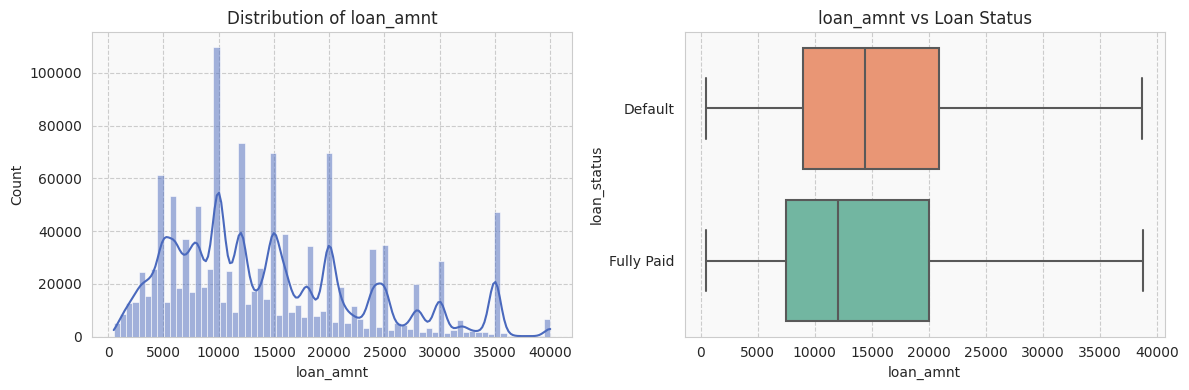

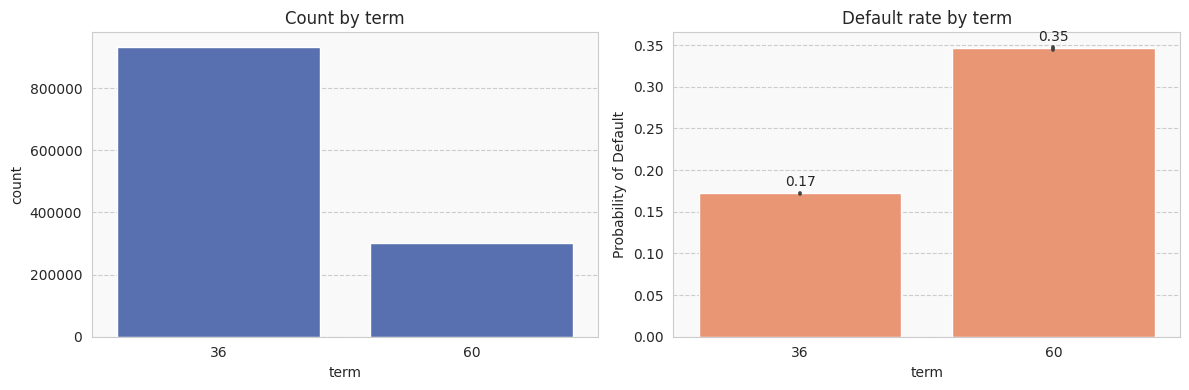

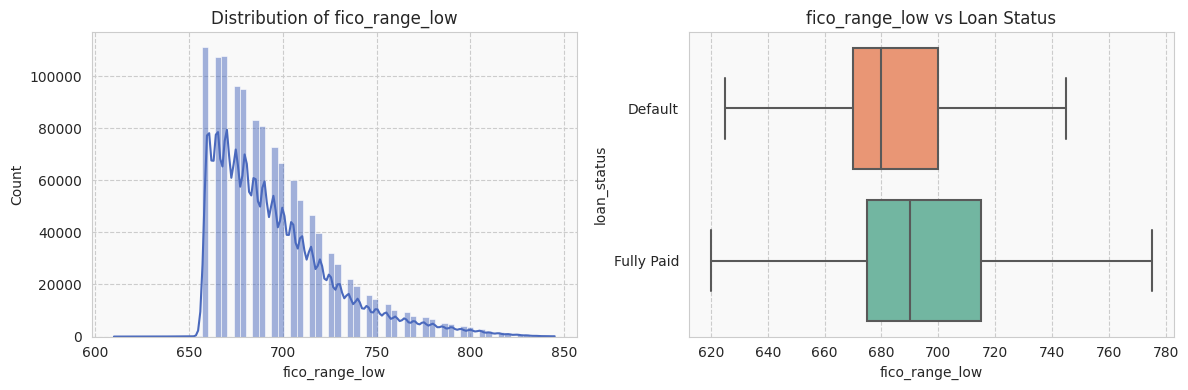

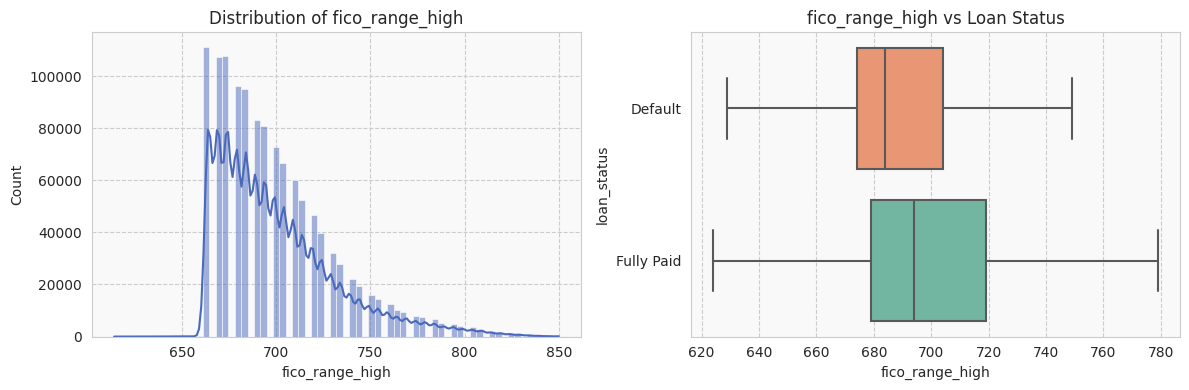

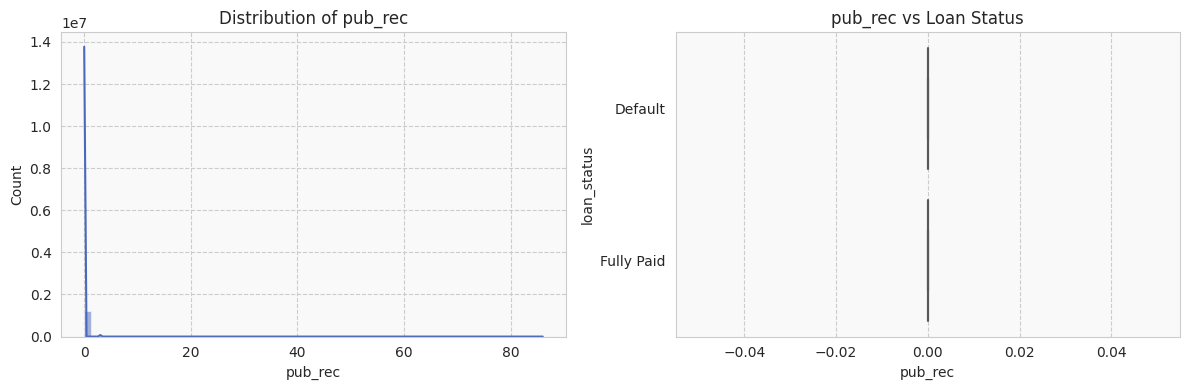

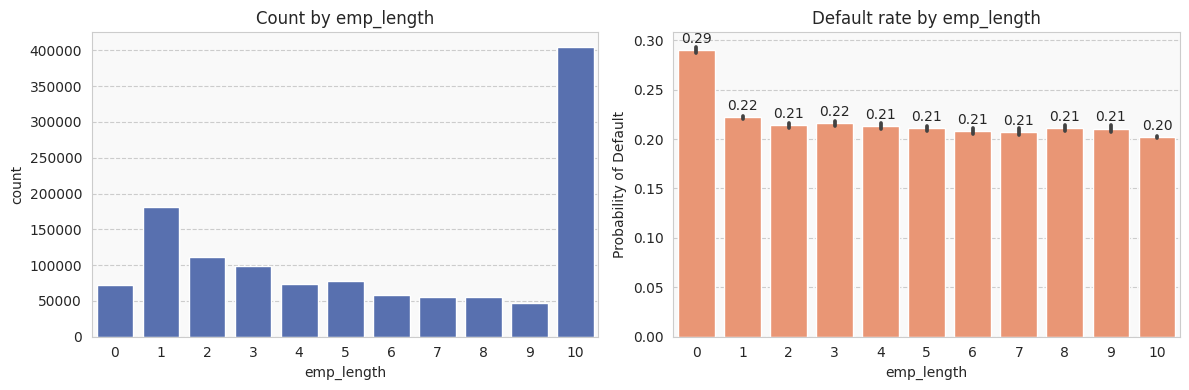

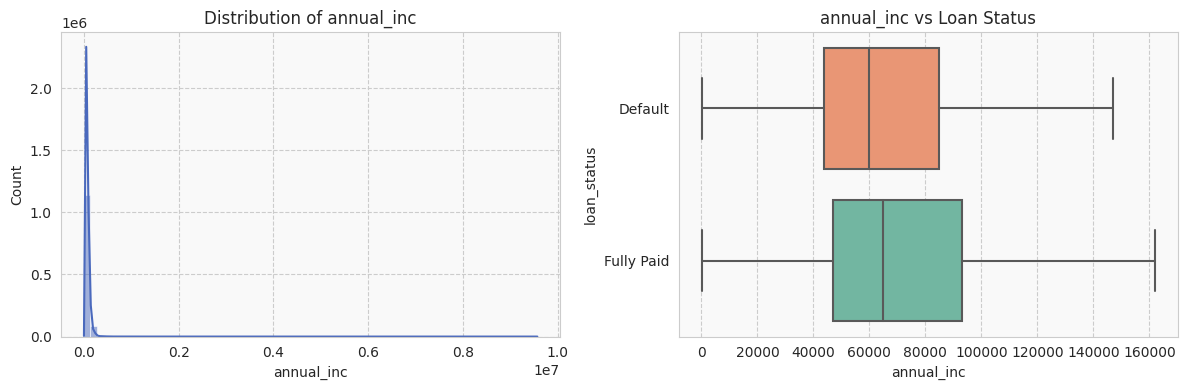

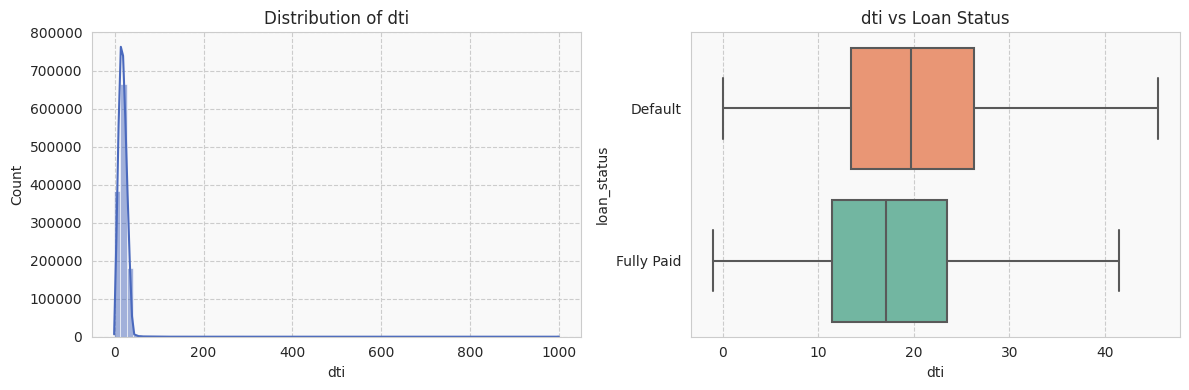

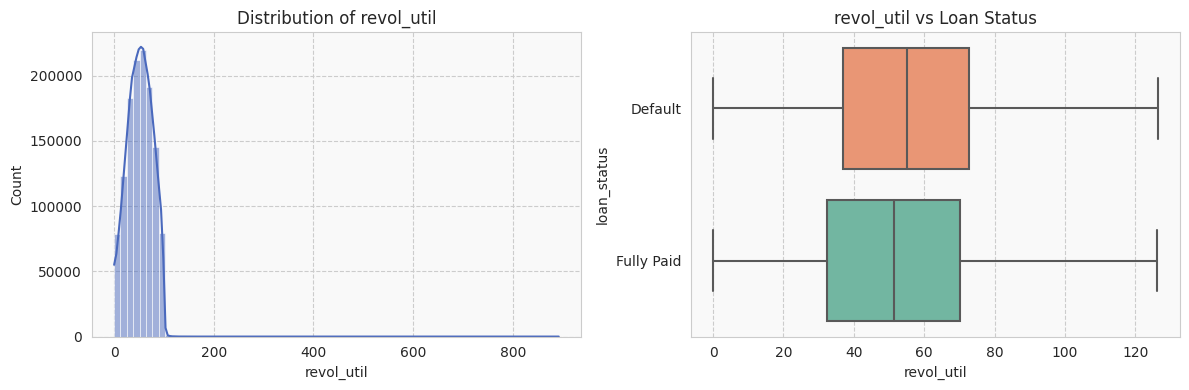

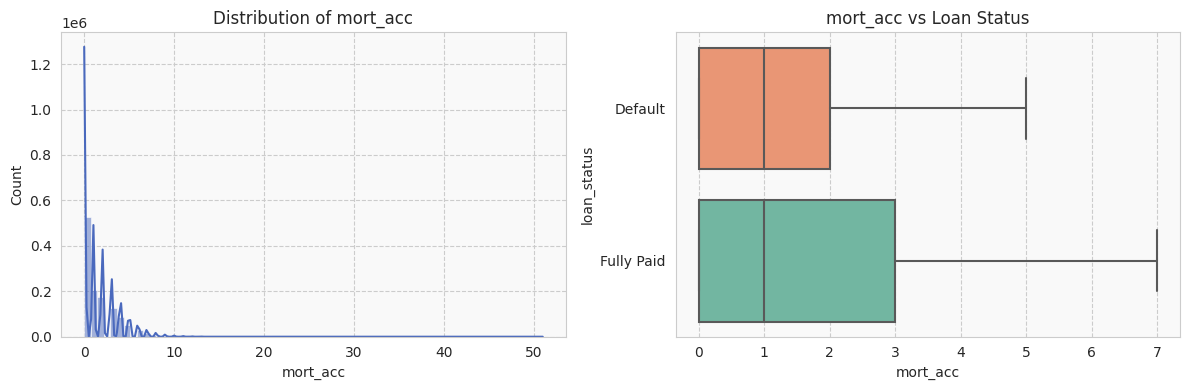

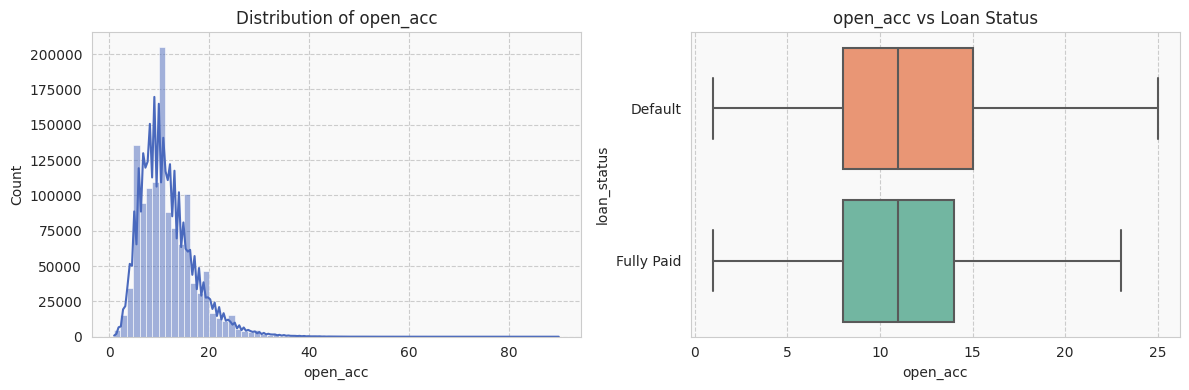

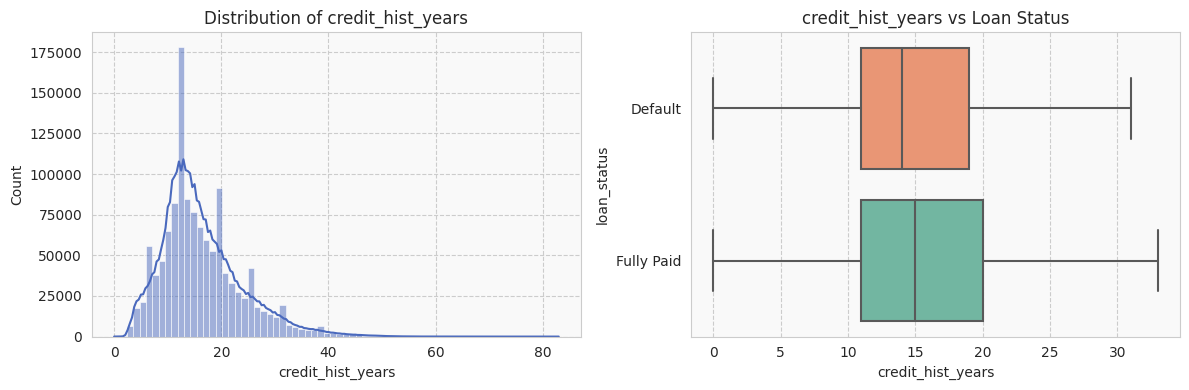

In [20]:
num_cols = train.select_dtypes(exclude='object').columns.drop(['target_num','issue_d','earliest_cr_line'])
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if col in ['term','emp_length']:
        axes[0]=sns.countplot(data=train, x=col, ax=axes[0], color="#4a69bd", edgecolor='white')
        axes[0].set_title(f'Count by {col}')
    
        axes[1]=sns.barplot(data=train, x=col, y='target_num', ax=axes[1], color=colors[1])
        axes[1].set_title(f'Default rate by {col}')
        axes[1].set_ylabel('Probability of Default')
    
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.2f', padding=3)

    else:
        axes[0]=sns.histplot(train, x=col, kde=True, ax=axes[0], bins=70, color="#4a69bd", edgecolor='white')
        axes[0].set_title(f'Distribution of {col}')
        
        axes[1]=sns.boxplot(train, x=col, y='loan_status', ax=axes[1], palette=colors[:2][::-1], showfliers=False)
        axes[1].set_title(f'{col} vs Loan Status')

    axes[0].set_facecolor('#f9f9f9')
    axes[1].set_facecolor('#f9f9f9')
    plt.tight_layout()
    plt.show()

## Removing outliers

Most features are highly **right-skewed**. Since I want to compare *Logistic Regression* with *RandomForestClasifier* and *XGBClassifier*, I will remove outliers to meet the requirements of the linear model. This ensures that extreme values do not influence the regression results, while being neutral for the tree based models.

`annual_inc`: Filtered to focus on typical borrowers (< $300 000).

`pub_rec`: Binarized (0: no records, 1: one or more records) I also change the type of plot for this feature.

`dti`: Restricted to the (0,60) range.

`revol_util`: Limited to <=150.

`open_acc ` & `mort_acc`: Capped at 40 and 10 respectively.

`credit_hist_years`: Limited to <60.

In [21]:
print(f'Number of records before: {len(train)} ')
train = train.loc[train['annual_inc']<=300000]
train['pub_rec'] = (train['pub_rec'] > 0).astype(int)
train=train.loc[(train['dti']<=60)&(train['dti']>=0)]
train=train.loc[train['revol_util']<=150]
train=train.loc[train['open_acc']<40]
train=train.loc[train['mort_acc']<=10]
train=train.loc[train['credit_hist_years']<60]
print(f'Number of records after: {len(train)} ')

Number of records before: 1234836 
Number of records after: 1222111 


### Post-cleaning visualization

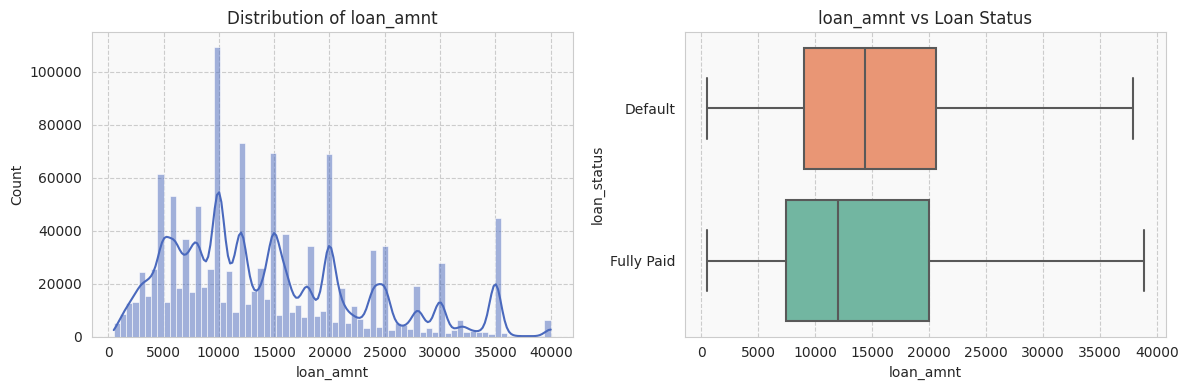

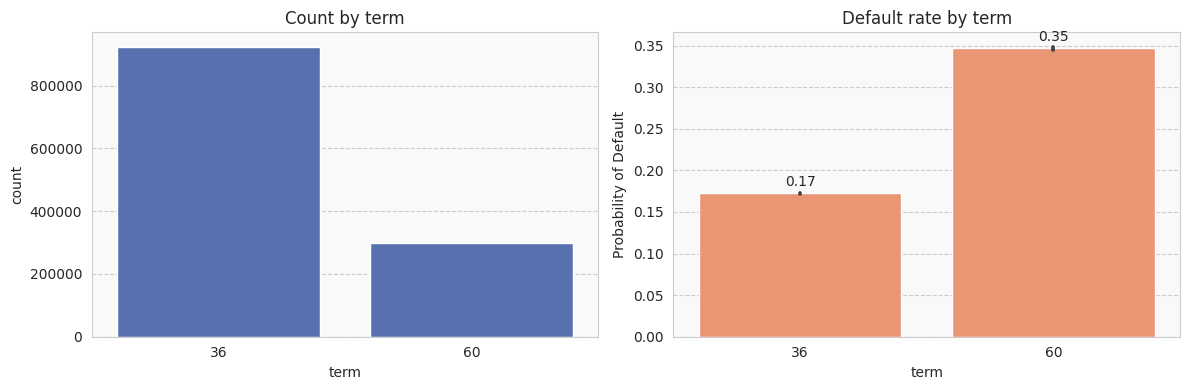

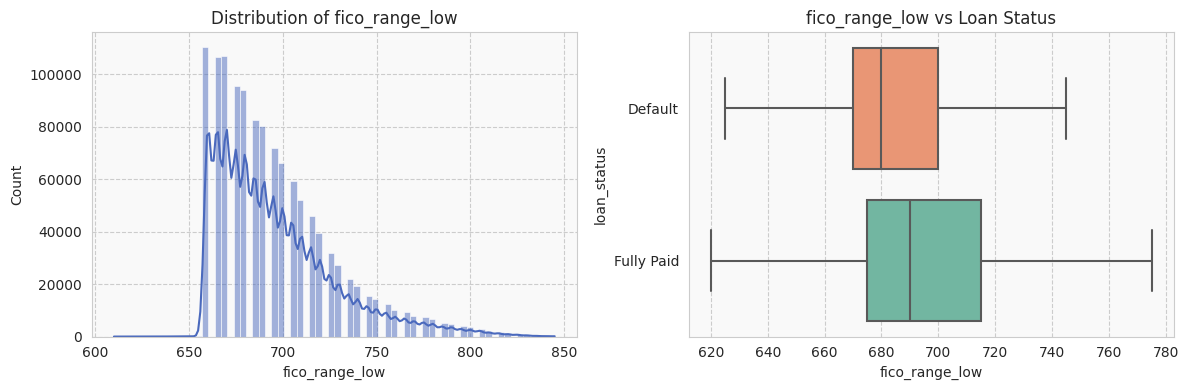

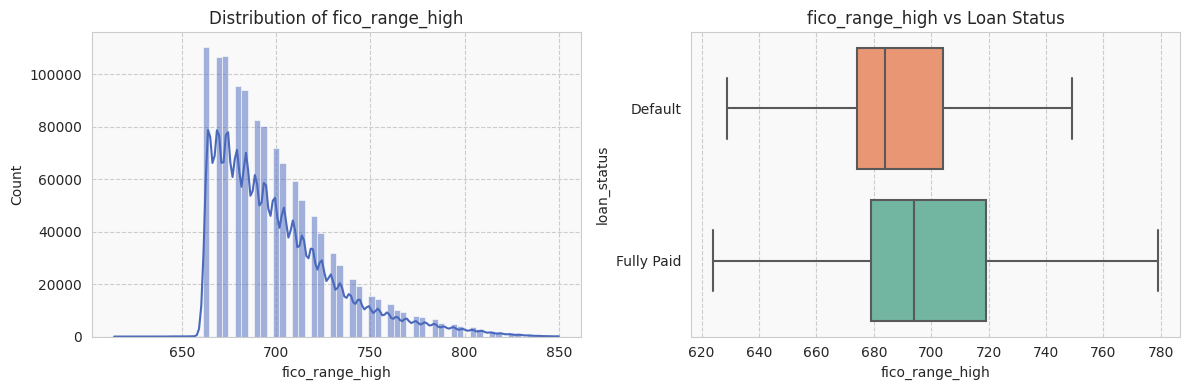

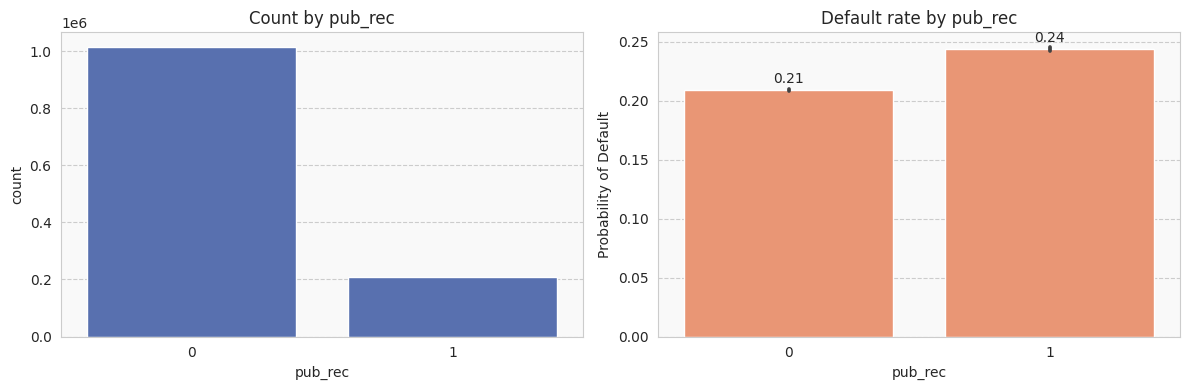

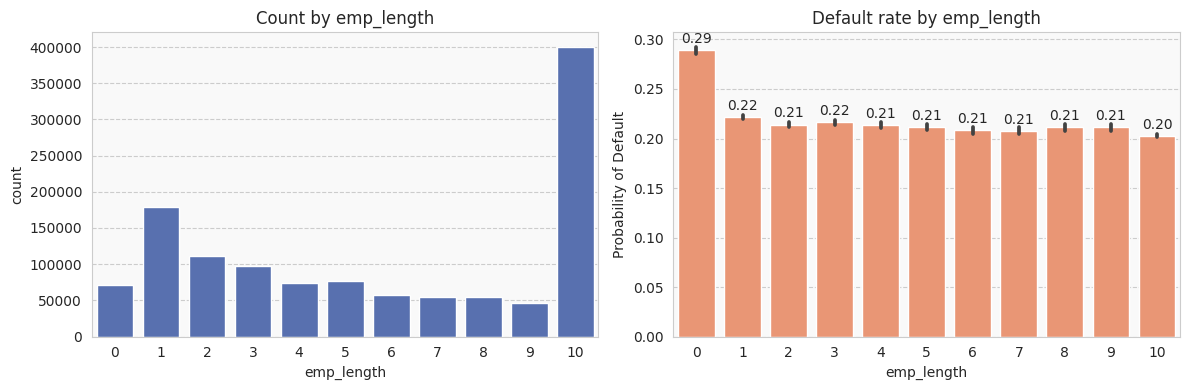

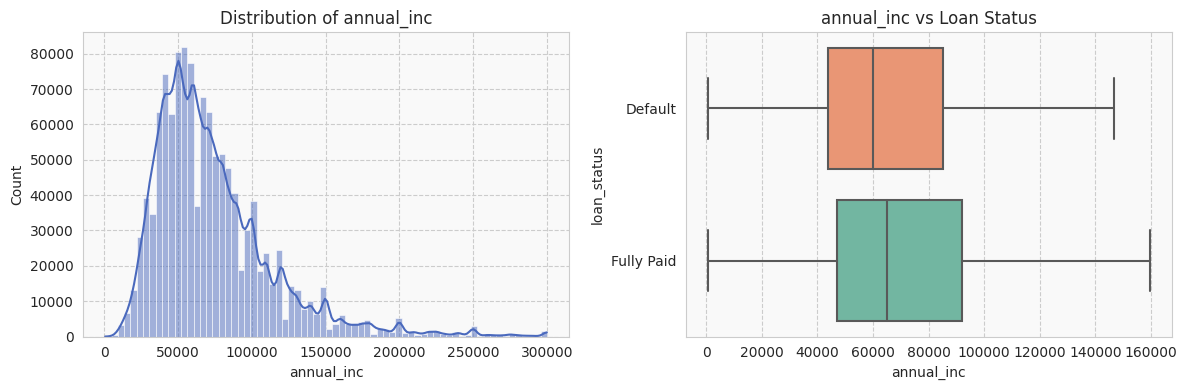

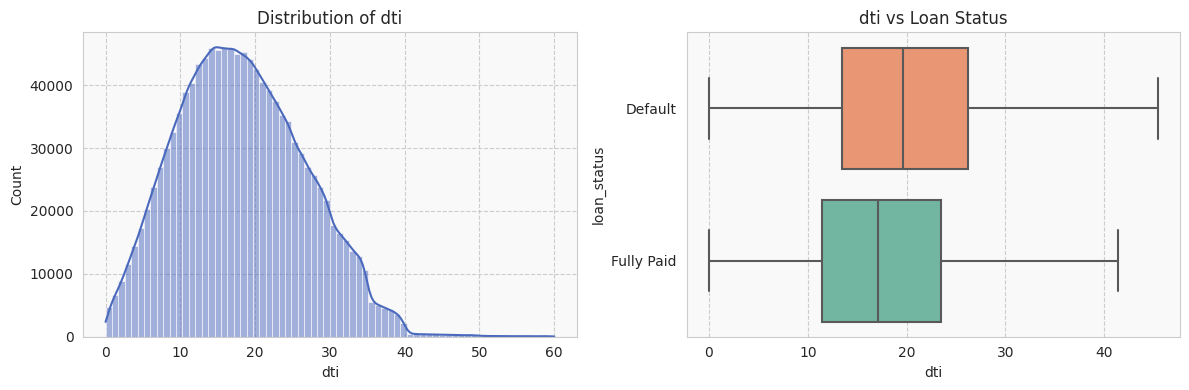

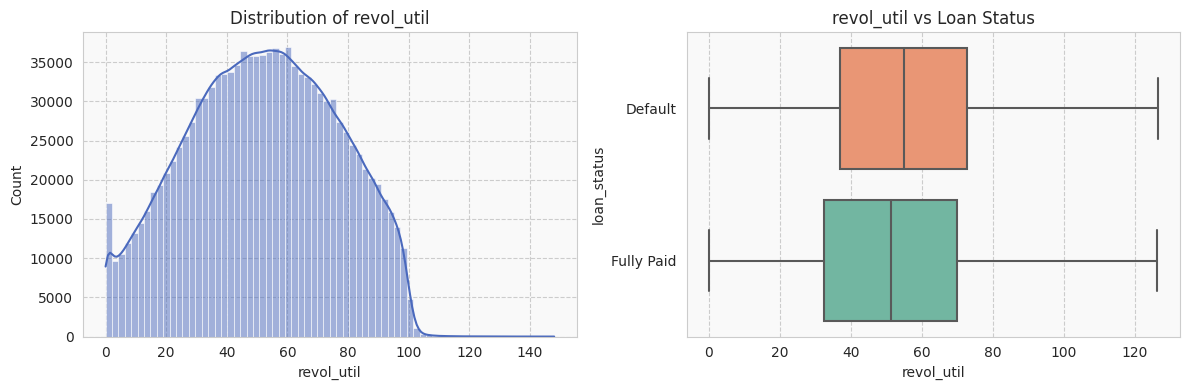

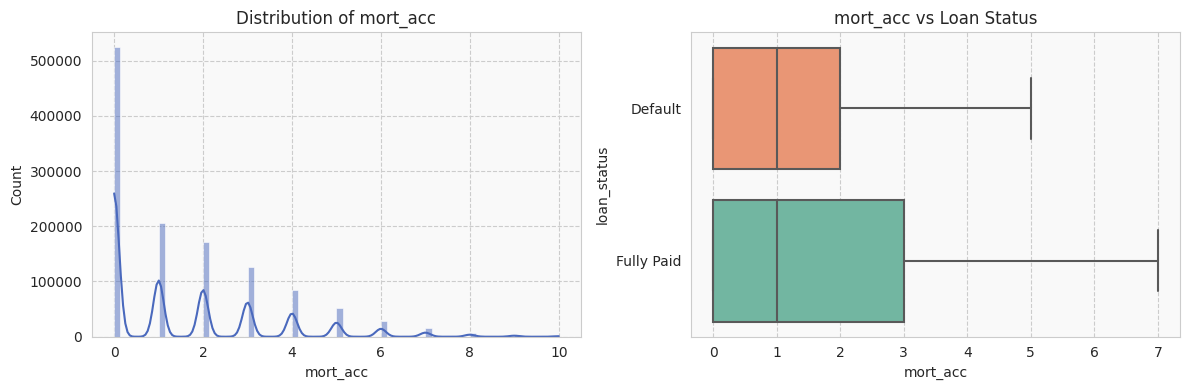

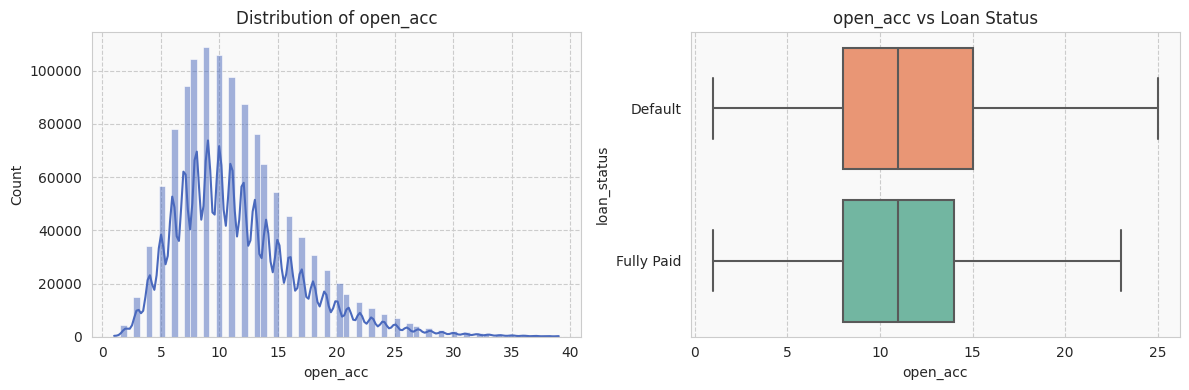

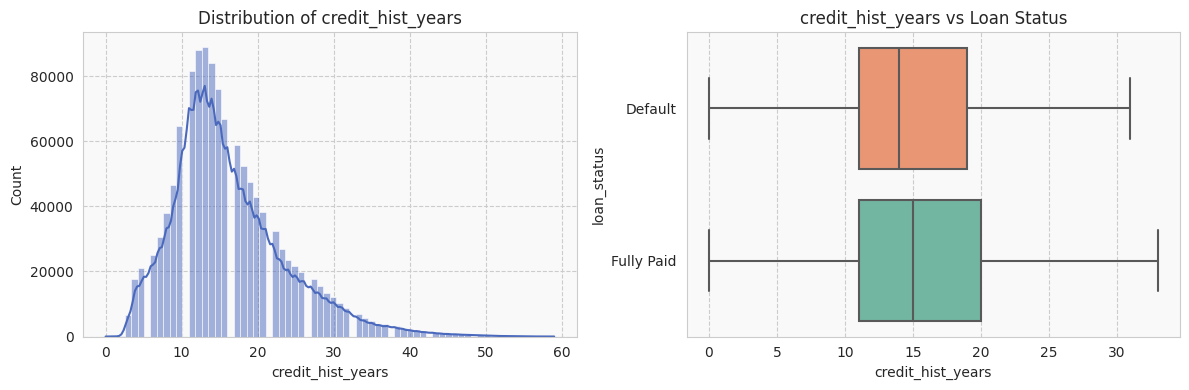

In [22]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if col in ['term','emp_length','pub_rec']:
        axes[0]=sns.countplot(data=train, x=col, ax=axes[0], color="#4a69bd", edgecolor='white')
        axes[0].set_title(f'Count by {col}')
    
        axes[1]=sns.barplot(data=train, x=col, y='target_num', ax=axes[1], color=colors[1])
        axes[1].set_title(f'Default rate by {col}')
        axes[1].set_ylabel('Probability of Default')
    
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt='%.2f', padding=3)

    else:
        axes[0]=sns.histplot(train, x=col, kde=True, ax=axes[0], bins=70, color="#4a69bd", edgecolor='white')
        axes[0].set_title(f'Distribution of {col}')
        
        axes[1]=sns.boxplot(train, x=col, y='loan_status', ax=axes[1], palette=colors[:2][::-1], showfliers=False)
        axes[1].set_title(f'{col} vs Loan Status')

    axes[0].set_facecolor('#f9f9f9')
    axes[1].set_facecolor('#f9f9f9')
    plt.tight_layout()
    plt.show()

# 🏷️Categorical features analysis

I use **countplots** to observe the frequency of each category and **barplots** to analyze the default rate across cateogories.

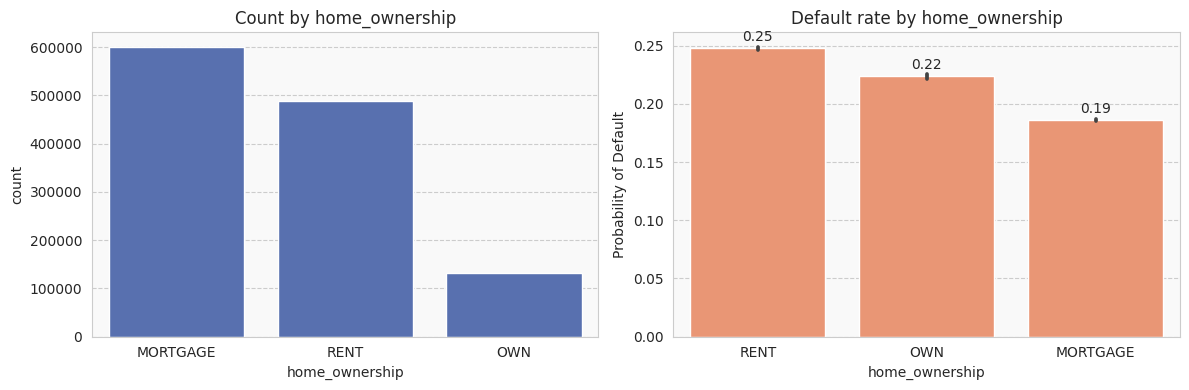

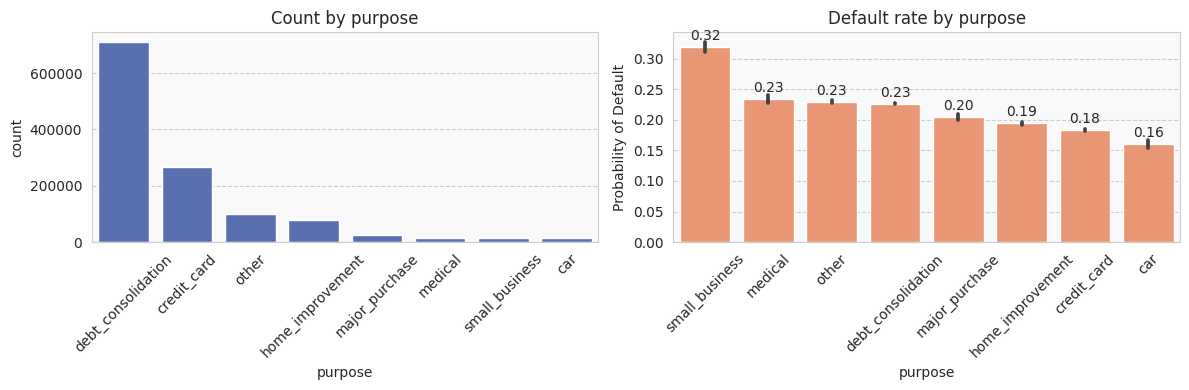

In [23]:
cat_cols = train.select_dtypes(exclude=np.number).columns.drop('loan_status')
for col in cat_cols:
    order1=train.groupby(col)['target_num'].count().sort_values(ascending=False).index
    order2 = train.groupby(col)['target_num'].mean().sort_values(ascending=False).index
    fig,axes = plt.subplots(1,2,figsize=(12,4))
    axes[0] = sns.countplot(train,x=col,ax=axes[0],color="#4a69bd", edgecolor='white',order=order1)
    axes[0].set_title(f'Count by {col}')
    
    axes[1]=sns.barplot(train,x=col,y='target_num',color=colors[1],order=order2,ax=axes[1])
    axes[1].set_title(f'Default rate by {col}')
    axes[1].set_ylabel('Probability of Default')
    for container in axes[1].containers:
                axes[1].bar_label(container, fmt='%.2f', padding=3)
    if col=='purpose':
        axes[0].tick_params(axis='x',rotation=45)
        axes[1].tick_params(axis='x',rotation=45)
    axes[0].set_facecolor('#f9f9f9')
    axes[1].set_facecolor('#f9f9f9')
    plt.tight_layout()
    plt.show



# 🔄 Data preprocessing

I create a **cleaner** function to ensure the test set is synchronized with every change made previously to the train set. While I dropped outlier rows in the training set, here I use **capping** or **median/mode imputation** to maintain the same test set size. To prevent data leakage, medians and modes used in this function were calculated strictly from the training data.

## Cleaning function

In [24]:
imput_values = {}
cols = train.columns.drop(['loan_status','target_num'])
for col in cols:
    if train[col].dtype =='float64':
        imput_values[col]=train[col].median()
    else:
        imput_values[col]=train[col].mode()[0]
print('Calculated values from train: ')
print(imput_values)
train = train.drop(['earliest_cr_line','issue_d'],axis=1)

Calculated values from train: 
{'loan_amnt': 12000.0, 'term': 36, 'fico_range_low': 690.0, 'fico_range_high': 694.0, 'pub_rec': 0, 'emp_length': 10, 'home_ownership': 'MORTGAGE', 'annual_inc': 65000.0, 'purpose': 'debt_consolidation', 'dti': 17.67, 'revol_util': 52.1, 'mort_acc': 1.0, 'earliest_cr_line': 2001, 'open_acc': 11.0, 'issue_d': 2015, 'credit_hist_years': 13}


In [25]:
def cleaner(data):
    df = data.copy()
    
    if 'mort_acc' in df.columns: 
        df['mort_acc'] = df['mort_acc'].fillna(0)
    if 'emp_length' in df.columns: 
        df['emp_length'] = df['emp_length'].fillna(0)
    
    if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
        df['issue_d'] = df['issue_d'].apply(lambda x: int(x.split('-')[1]) if type(x)==str else np.nan)
        df['earliest_cr_line'] = df['earliest_cr_line'].apply(lambda x: int(x.split('-')[1]) if type(x)==str else np.nan)
        df['credit_hist_years'] = df['issue_d'] - df['earliest_cr_line']
        df = df.drop(columns=['issue_d', 'earliest_cr_line'])

    if 'emp_length' in df.columns:
        if df['emp_length'].dtype == 'O' or df['emp_length'].dtype == 'string':
            df['emp_length'] = df['emp_length'].astype(str).str.replace(r'years?|<|\+', '', regex=True).str.strip()
        df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')
    
    if 'term' in df.columns:
        if df['term'].dtype == 'O' or df['term'].dtype == 'string':
            df['term'] = df['term'].str.replace('months', '').str.strip()
        df['term'] = pd.to_numeric(df['term'], errors='coerce')

    for col in df.columns:
        if col in imput_values:
            df[col] = df[col].fillna(imput_values[col])

    if 'annual_inc' in df.columns: 
        df['annual_inc'] = df['annual_inc'].clip(upper=300000)
    if 'pub_rec' in df.columns:
        df['pub_rec'] = (df['pub_rec'] > 0).astype(int)
    if 'dti' in df.columns:
        df['dti'] = df['dti'].clip(lower=0, upper=60)
    if 'revol_util' in df.columns:
        df['revol_util'] = df['revol_util'].clip(upper=150)
    if 'open_acc' in df.columns:
        df['open_acc'] = df['open_acc'].clip(upper=39)
    if 'mort_acc' in df.columns:
        df['mort_acc'] = df['mort_acc'].clip(upper=10)
    if 'credit_hist_years' in df.columns:
        df['credit_hist_years'] = df['credit_hist_years'].clip(upper=59)

    if 'home_ownership' in df.columns:
        to_keep = ['MORTGAGE', 'RENT', 'OWN']
        df['home_ownership'] = df['home_ownership'].apply(lambda x: x if x in to_keep else 'MORTGAGE')

    if 'purpose' in df.columns:
        to_merge = ['vacation', 'wedding', 'renewable_energy', 'educational', 'moving', 'house']
        df.loc[df['purpose'].isin(to_merge), 'purpose']='other'
    
    return df


I check the skewnesses of numerical columns to decide the strategy of data preprocessing.

In [26]:
print('Skewness:')
for col in num_cols:
    print(f'{col}: {round(train[col].skew(),2)}')

Skewness:
loan_amnt: 0.79
term: 1.19
fico_range_low: 1.29
fico_range_high: 1.29
pub_rec: 1.76
emp_length: -0.08
annual_inc: 1.73
dti: 0.32
revol_util: -0.07
mort_acc: 1.33
open_acc: 1.11
credit_hist_years: 1.08


## Strategy
**Skewness <1**: For features with low to moderate skewness, I will apply **standard scaling**  (StandardScaler) to bring all variables to an uniform scale.

**Skewness >=1**: For highly skewed features, I will first apply a **logarithmic transformation** (log1p) to normalize the distribution, combined with Standard Scaling. (excluding `term` which only values of 36 and 60 and `pub_rec` which is binary)

`term`: transformed into binary (0: 36, 1: 60).

`fico_range_high` & `fico_range_low`: simplified into one freature `fico` which is their mean value.

`home_ownership` & `purpose`: transformed using **OneHotEncoder**.

In [27]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
def engineer(data):
    df = data.copy()
    
    if 'term' in df.columns:
        if df['term'].isin([36, 60]).any():
            df['term'] = df['term'].apply(lambda x: 0 if x == 36 else 1)
            
    if 'fico_range_high' in df.columns and 'fico_range_low' in df.columns:
        df['fico'] = (df['fico_range_high'] + df['fico_range_low']) / 2
        df = df.drop(['fico_range_high', 'fico_range_low'], axis=1)
        
    to_log = ['annual_inc', 'mort_acc', 'fico', 'open_acc', 'credit_hist_years']
    for col in to_log:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            
    return df
to_scale = ['annual_inc', 'mort_acc', 'fico', 'loan_amnt', 'dti', 'revol_util', 'open_acc','credit_hist_years']
to_ohe = ['home_ownership','purpose']
scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop=None)
preprocessor = ColumnTransformer(transformers=[
    ('scaler',scaler,to_scale),
    ('ohe',ohe,to_ohe)
],remainder='passthrough')

# 🏋️ Model Training 

To find the most effective model, I evaluate three distinct algorithms: *LogisticRegression*, *RandomForestClassifier*, and *XGBClassifier*.

**Class imbalance:** To tell the models to pay more attention to the minority class, I use scale_pos_weight ratio for XGBClassifier and the balanced class weight parameter for others.

**Validation:** I use 3-fold stratified cross validation. The primary evaluation metric at this stage is ROC AUC score, as it measures the ability to distinguish between  **Fully Paid** and **Default** statuses. Metrics like recall and precision will be analyzed during the final evaluation of the best performing model.

**Pipeline:** Feature engineering and preprocessing are integrtaed within one pipeline ensuring that all transformations are fitted only on the training folds during cross-validation and that every model sees the same data.

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.model_selection import cross_val_score,StratifiedKFold


train = train.reset_index(drop=True)
X_train = train.drop(['loan_status', 'target_num'], axis=1)
y_train = train['target_num']

counts = y_train.value_counts()
ratio = (counts[0] / counts[1])

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=100,
        class_weight = 'balanced',
        random_state=42,
        max_depth=10,
        max_samples=0.5,
        n_jobs=-1
    ),
    'XGBClassifier': XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=ratio,
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        device='cuda',
        tree_method = 'hist',
    )
}

for name, model in models.items():
    print(f'\nModel: {name}')
    steps = [
        ('cleaner',FunctionTransformer(cleaner)),
        ('engineer', FunctionTransformer(engineer)),
        ('preprocessor', preprocessor),
        ('model', model) 
    ]
    pipe=Pipeline(steps)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=10)
    cv=cross_val_score(pipe,X_train,y_train,scoring='roc_auc',cv=skf,n_jobs=1)
    print(f"Mean ROC AUC score on 3 folds: {round(cv.mean(),3)}")


Model: LogisticRegression
Mean ROC AUC score on 3 folds: 0.686

Model: RandomForestClassifier
Mean ROC AUC score on 3 folds: 0.689

Model: XGBClassifier
Mean ROC AUC score on 3 folds: 0.696


## Optimization

**XGBClassifier** performed the best with a starting ROC AUC score of 0.696. To improve this, I use **Optuna** to find the best possible hyperparameters. Unlike RandomSearch or GridSearch, optuna "learns" from previous iterations, focusing its searches on areas that are more likely to produce the highest scores.

In [30]:
%%capture

import optuna
from optuna.integration import OptunaSearchCV
best_model = Pipeline(steps=[
    ('cleaner',FunctionTransformer(cleaner)),
    ('engineer', FunctionTransformer(engineer)),
    ('preprocessor', preprocessor),
    ('model', models['XGBClassifier'])
])

param_distributions = {
    'model__learning_rate': optuna.distributions.FloatDistribution(0.01, 0.05, log=True),
    'model__n_estimators': optuna.distributions.IntDistribution(500, 1800, step=100),
    'model__max_depth': optuna.distributions.IntDistribution(3, 12),
    'model__min_child_weight': optuna.distributions.IntDistribution(50, 500),
    'model__subsample': optuna.distributions.FloatDistribution(0.5, 0.9),
    'model__colsample_bytree': optuna.distributions.FloatDistribution(0.5, 0.9),
    'model__gamma': optuna.distributions.FloatDistribution(0, 10),
    'model__reg_alpha': optuna.distributions.FloatDistribution(1e-4, 10.0, log=True),
    'model__reg_lambda': optuna.distributions.FloatDistribution(1e-4, 10.0, log=True),
    'model__max_bin': optuna.distributions.IntDistribution(256, 512, step=128)
}

optuna_search = OptunaSearchCV(
    estimator=best_model,
    param_distributions=param_distributions,
    n_trials=25,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    verbose=1,
    n_jobs=1
)

optuna_search.fit(X_train, y_train)

In [ ]:
print(f"Best mean ROC AUC score on 3 folds (optimized model): {round(optuna_search.best_score_,3)}")
print(f"Params: {optuna_search.best_params_}")
best_model = optuna_search.best_estimator_

Best mean ROC AUC score on 3 folds (optimized model): 0.7
Params: {'model__learning_rate': 0.011924602245563574, 'model__n_estimators': 1700, 'model__max_depth': 8, 'model__min_child_weight': 316, 'model__subsample': 0.5383843756844012, 'model__colsample_bytree': 0.6885003397151922, 'model__gamma': 2.1679840274705913, 'model__reg_alpha': 2.8434619870344284, 'model__reg_lambda': 0.8400547444120104, 'model__max_bin': 512}


# 📝 Model evaluation

In [32]:

probs = best_model.predict_proba(X_test)[:, 1]
preds = best_model.predict(X_test)

train_probs = best_model.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train,train_probs)

auc_test = round(roc_auc_score(y_test, probs), 3)
gini = round(2 * auc_test - 1, 3)
print("TRAIN DATA")
print(f"ROC AUC score: {round(auc_train,3)}")
print("\nTEST DATA")
print(f"ROC AUC score: {round(auc_test,3)}")
print(f"Gini: {gini}")
print(f'\nClassification report (basic threshold of 0.5)):\n{classification_report(y_test, preds)}')

threshold = 0.4
custom_preds = (probs >= threshold).astype(int)
print(f"\n Classification report (custom threshold of {threshold})\n{classification_report(y_test,custom_preds)}")

TRAIN DATA
ROC AUC score: 0.713

TEST DATA
ROC AUC score: 0.701
Gini: 0.402

Classification report (basic threshold of 0.5)):
              precision    recall  f1-score   support

           0       0.87      0.65      0.74    107874
           1       0.33      0.64      0.44     29518

    accuracy                           0.64    137392
   macro avg       0.60      0.64      0.59    137392
weighted avg       0.75      0.64      0.68    137392


 Classification report (custom threshold of 0.4)
              precision    recall  f1-score   support

           0       0.90      0.42      0.58    107874
           1       0.28      0.83      0.42     29518

    accuracy                           0.51    137392
   macro avg       0.59      0.63      0.50    137392
weighted avg       0.77      0.51      0.54    137392



## Performance analysis


**High stability & No overfitting:** the difference between train ROC AUC (0.713) and test ROC AUC (0.701) is neglible. It means that model solidly generalizes new, unseen data and has learned real risk patterns rather than memorizing training set.

**Predictive Power**: ROC AUC score (0.701) and Gini (0.402) both confirm that model is effective at ranking cleints from lowest to highest risk. A Gini coefficient above 0.4 and ROC AUC above 0.7 is generally considered good, indicating that the model has discriminatory power.

**Flexibility**: The model adapts to varying business risk appetites via threshold tuning. A balanced approach (0.5 cutoff) captures 65% of defaults, while a conservative strategy (0.4 cutoff) increases recall to 84%, serving as an aggressive filter to minimize potential financial exposure.

## Feature importances

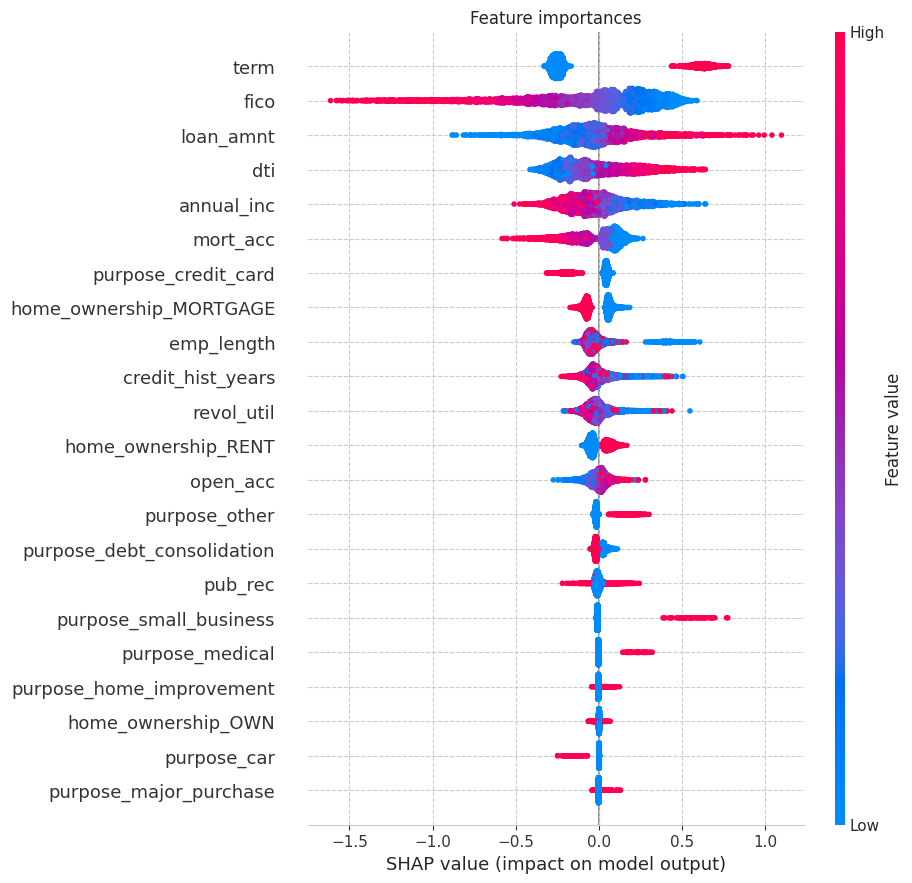

In [33]:
import shap
SAMPLE_SIZE = 5000 

X_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)

step_cleaner = best_model.named_steps['cleaner']
step_engineer = best_model.named_steps['engineer']
step_preprocessor = best_model.named_steps['preprocessor']
step_model = best_model.named_steps['model']

X_sample = step_cleaner.transform(X_sample)
X_sample = step_engineer.transform(X_sample)
X_sample = step_preprocessor.transform(X_sample)

feature_names = step_preprocessor.get_feature_names_out()
names= []
for name in feature_names:
    name = name.split('__')[1]
    names.append(name)

explainer = shap.Explainer(step_model)
shap_values = explainer(X_sample)
shap_values.feature_names = names
plt.figure(figsize=(10,6))
plt.title('Feature importances')
shap.plots.beeswarm(shap_values, max_display=23,show=False)
plt.savefig('feature_importances',bbox_inches="tight", dpi=300)


# 💾 Model & data saving

In [34]:
import joblib
train.to_csv('train',index=False)
joblib.dump(best_model, 'credit_model.pkl')

['credit_model.pkl']